## Imports and plotting parameters

In [21]:
from src import *

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    'text.latex.preamble':r'\usepackage{amsmath}',
    'text.latex.preamble':r'\usepackage{fourier}'
})
w, l, l_log = 1.25, 10, 6
pad, lpad, shrink = 0.12, 5, 0.8

## Simulation outputs and normalizations 

In [22]:
# Reading the .ini file
conf = inifix.load("idefix.ini")
n_average = int(conf["TimeIntegrator"]["tstop"] / conf["Output"]["analysis"]) + 1
n_vtk = int(conf["TimeIntegrator"]["tstop"] / conf["Output"]["vtk"]) + 1
r_min = conf["Grid"]["X1-grid"][1]
r_max = conf["Grid"]["X1-grid"][-1]
n_r = conf["Grid"]["X1-grid"][2]
epsilon = conf["Setup"]["epsilon"]
alpha = conf["Setup"]["alpha"]
densityFloor = conf["Setup"]["densityFloor"]
gravity = conf["Setup"]["gravity"]
beta_0 = conf["Setup"]["tilt"] * np.pi/180
spin = conf["Setup"]["spin"]

# Reading the analysis files
t, M_tot = READ_BOX_AVERAGE()
r, Sigma, rho_mean, L, beta, gamma, rho_Vr, rho_Vperp = READ_RADIAL_AVERAGE(n_average, n_r, beta_0)

# Time
r_norm = r_min
grad_Phi = 0
if gravity == "Kepler":
    grad_Phi = 1/r_norm**2
elif gravity == "Einstein":
    grad_Phi = 1/r_norm**2 + 6/r_norm**3
omega_orbit = np.sqrt(r_norm * grad_Phi) / (2*np.pi*r_norm)
n_orbit = 1500
t *= omega_orbit
T, R = np.meshgrid(t, r, indexing="ij")

# Warp profile
L_unit = np.zeros_like(L)
L_unit[:,:,0] = L[:,:,0] / np.sqrt(L[:,:,0]**2 + L[:,:,1]**2 + L[:,:,2]**2)
L_unit[:,:,1] = L[:,:,1] / np.sqrt(L[:,:,0]**2 + L[:,:,1]**2 + L[:,:,2]**2)
L_unit[:,:,2] = L[:,:,2] / np.sqrt(L[:,:,0]**2 + L[:,:,1]**2 + L[:,:,2]**2)
psi = R * np.sqrt(np.gradient(L_unit[:,:,0], r, axis=1)**2 + np.gradient(L_unit[:,:,1], r, axis=1)**2 + np.gradient(L_unit[:,:,2], r, axis=1)**2)

# Nodal and precession frequencies
# To do

# Accretion rate
M_dot = np.mean(2*np.pi*R * Sigma * (-rho_Vr / rho_mean), axis=0)
omega_K = KEPLER(r)
v_K = r * omega_K
c_s = epsilon * v_K
M_dot_visc = 2*np.pi*r * Sigma[0,:] * (alpha*epsilon*c_s)
omega_perp = np.mean(rho_Vperp / (R * rho_mean), axis=0)
kappa2_perp = 4*omega_perp**2 + 2*r*omega_perp * np.gradient(omega_perp, r)

## First VTK velocity field

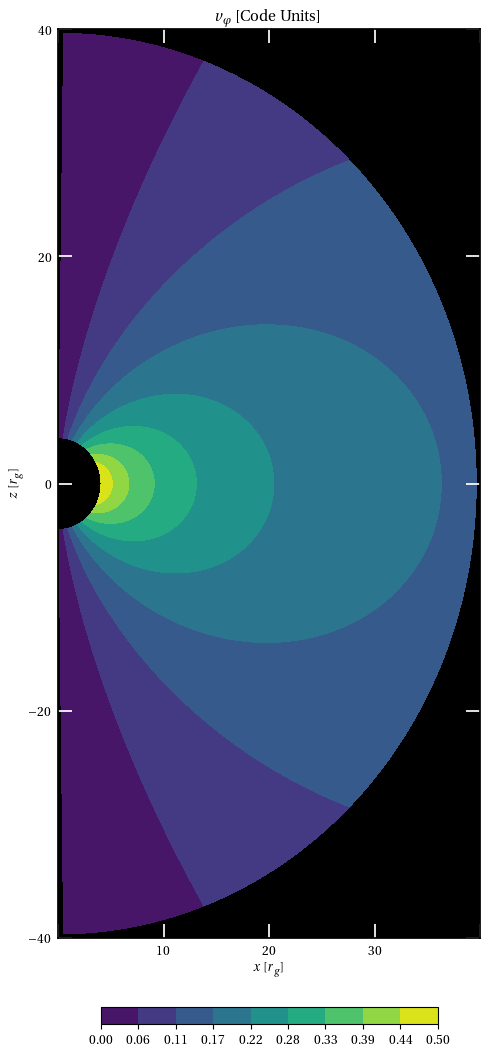

In [23]:
r_vtk, theta_vtk, phi_vtk, rho, v_r, v_theta, v_phi, _ = READ_VTK(0)
R, TH = np.meshgrid(r_vtk, theta_vtk)
phi_cut_plus = np.where(phi_vtk >= 0)[0][0]
X_cut_plus, Z = R*np.sin(TH)*np.cos(phi_vtk[phi_cut_plus]), R*np.cos(TH)
x_label = r"$x$ [$r_g$]"
y_label = r"$z$ [$r_g$]"

fig, axs = plt.subplots(1, figsize=(5, 12))

ax = axs
ax.set_title(r'$v_\varphi$ $[$Code Units$]$')
buff = np.max(np.abs(v_phi))
levels = np.linspace(0, buff, 10)
pc0 = ax.contourf(X_cut_plus, Z, v_phi[phi_cut_plus,:,:], cmap="viridis", levels=levels)
formats = tkr.FormatStrFormatter('%.2f')
cbar = fig.colorbar(pc0, ax=ax, location="bottom", pad=pad/2, shrink=shrink, format=formats, ticks=levels)
ax.tick_params(axis='both', direction='in', color='white', width=w, length=l, pad=lpad)
ax.set_facecolor("black")
ax.set_xlabel(x_label)
ax.set_ylabel(y_label)
ax.set_xlim((0,r_max))
xplot = np.linspace(0, r_max, 5)
xl = [f"{i:.0f}" for i in xplot]
xl[0] = ""
xl[-1] = ""
ax.set_xticks(xplot,xl)
ax.set_ylim((-r_max, r_max))
yplot = np.linspace(-r_max, r_max, 5)
ax.set_yticks(yplot)
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
for spine in ax.spines.values():
    spine.set_linewidth(w)

fig.tight_layout()
plt.savefig(f"./plots/Vphi0-{gravity}.png", bbox_inches='tight', dpi=300)
plt.show()
plt.close()

## Radial equilibrium

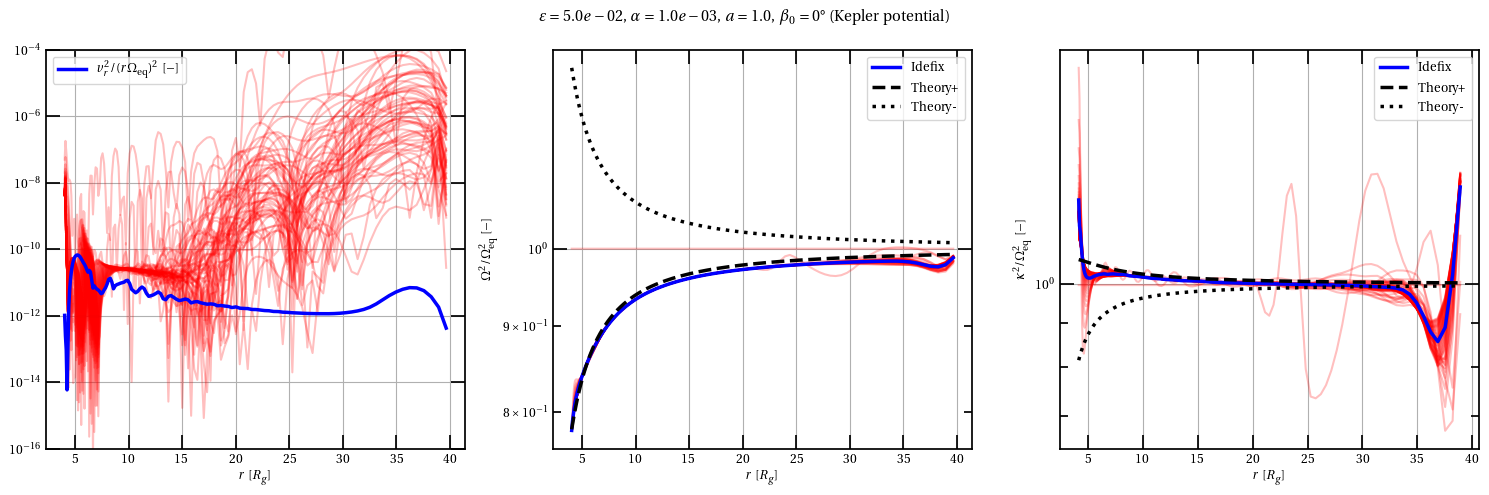

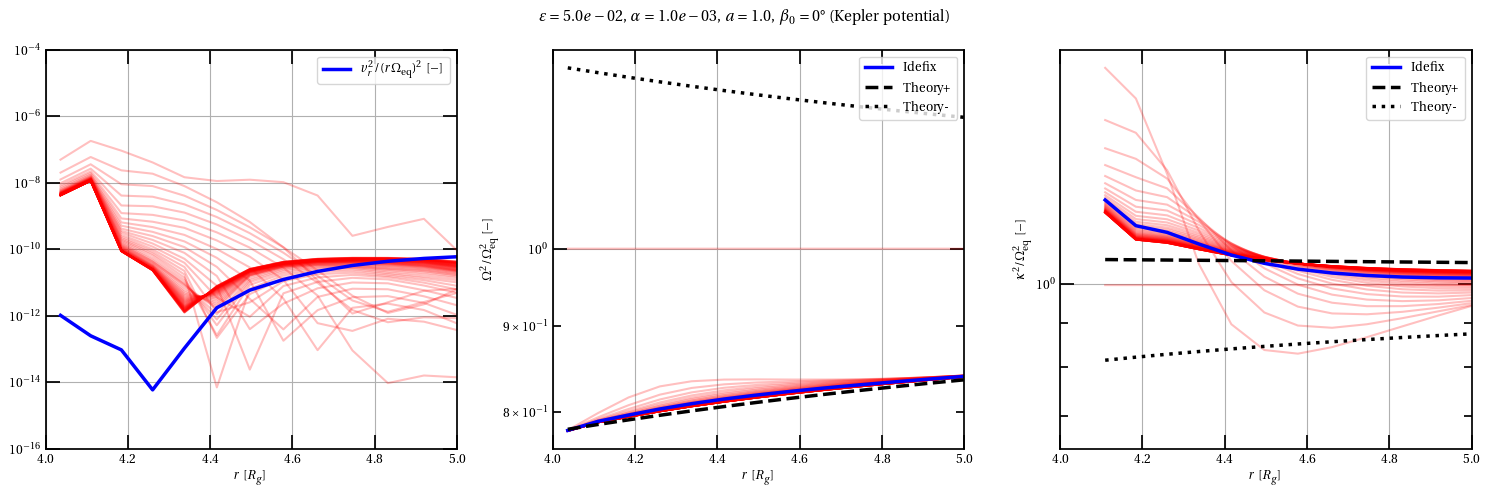

In [66]:
# obtaining the quantities
v_r_PLOT = np.zeros((n_vtk, n_r))
omega_PLOT = np.zeros((n_vtk, n_r))
kappa2_PLOT = np.zeros((n_vtk, n_r))
for n in range(n_vtk):
    r_vtk, theta_vtk, phi_vtk, rho, v_r, v_theta, v_phi, _ = READ_VTK(n)
    midplane = np.where(theta_vtk >= np.pi/2)[0][0]
    rho = rho[0,midplane,:]
    v_r = v_r[0,midplane,:]
    v_phi = v_phi[0,midplane,:]
    omega = v_phi / r_vtk
    kappa2 = 4*omega**2 + r_vtk*np.gradient(omega**2, r_vtk)

    v_r_PLOT[n,:] = v_r
    omega_PLOT[n,:] = omega
    kappa2_PLOT[n,:] = kappa2

v_r_mean = np.mean(v_r_PLOT**2, axis=0)
omega_mean = np.mean(omega_PLOT, axis=0)
kappa2_mean = np.mean(kappa2_PLOT, axis=0)

if gravity == "Kepler":
    omega_K = KEPLER(r)
elif gravity == "Einstein":
    omega_K = EINSTEIN(r)
omega_th_p, omega_th_m, kappa2_th_p, kappa2_th_m = THEORETICAL_ROTATION_CURVE(r_vtk, beta_0, spin, gravity, r_vtk)

# plotting them without zoom
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

ax = axs[0]
for i in range(n_vtk):
    if i%25 == 0:
        ax.plot(r, v_r_PLOT[i,:]**2/(r*omega_K)**2, color="red", alpha=0.25)
ax.plot(r, v_r_mean**2/(r*omega_K)**2, color="blue", label=r"$v_r^2/(r\Omega_\mathrm{eq})^2$ $[-]$", linewidth=2.5)
ax.set_xlabel(r"$r$ [$R_g$]")
ax.set_yscale("log")
ax.tick_params(axis='y', which='both', direction='in', right=True, width=w, length=l)
ax.tick_params(axis='x', which='both', direction='in', top=True, width=w, length=l)
ax.tick_params(axis='y', which='minor', length=l_log, width=w)
for spine in ax.spines.values():
        spine.set_linewidth(w)
ax.grid()
ax.legend()

ax = axs[1]
for i in range(n_vtk):
    if i%25 == 0:
        ax.plot(r, omega_PLOT[i,:]**2/omega_K**2, color="red", alpha=0.25)
ax.plot(r, omega_mean**2/omega_K**2, color="blue", label=r"Idefix", linewidth=2.5)
ax.plot(r, omega_th_p**2/omega_K**2, color="black", linestyle="dashed", label=r"Theory+", linewidth=2.5)
ax.plot(r, omega_th_m**2/omega_K**2, color="black", linestyle="dotted", label=r"Theory-", linewidth=2.5)
ax.set_xlabel(r"$r$ [$R_g$]")
ax.set_yscale("log")
ax.set_ylabel(r"$\Omega^2 / \Omega_\mathrm{eq}^2$ $[-]$")
ax.tick_params(axis='y', which='both', direction='in', right=True, width=w, length=l)
ax.tick_params(axis='x', which='both', direction='in', top=True, width=w, length=l)
ax.tick_params(axis='y', which='minor', length=l_log, width=w)
for spine in ax.spines.values():
        spine.set_linewidth(w)
ax.grid()
ax.legend()

ax = axs[2]
for i in range(n_vtk):
    if i%25 == 0:
        ax.plot(r[1:-1], kappa2_PLOT[i,1:-1]/omega_K[1:-1]**2, color="red", alpha=0.25)
ax.plot(r[1:-1], kappa2_mean[1:-1]/omega_K[1:-1]**2, color="blue", label=r"Idefix", linewidth=2.5)
ax.plot(r[1:-1], kappa2_th_p[1:-1]/omega_K[1:-1]**2, color="black", linestyle="dashed", label=r"Theory+", linewidth=2.5)
ax.plot(r[1:-1], kappa2_th_m[1:-1]/omega_K[1:-1]**2, color="black", linestyle="dotted", label=r"Theory-", linewidth=2.5)
ax.set_xlabel(r"$r$ [$R_g$]")
ax.set_yscale("log")
ax.set_ylabel(r"$\kappa^2/\Omega_\mathrm{eq}^2$ $[-]$")
ax.tick_params(axis='y', which='both', direction='in', right=True, width=w, length=l)
ax.tick_params(axis='x', which='both', direction='in', top=True, width=w, length=l)
ax.tick_params(axis='y', which='minor', length=l_log, width=w)
for spine in ax.spines.values():
        spine.set_linewidth(w)
ax.grid()
ax.legend()

fig.suptitle(rf"$\varepsilon = {epsilon:.1e}$, $\alpha = {alpha:.1e}$, $a = {spin:0.1f}$, $\beta_0 = {beta_0*180/np.pi:.0f}$° ({gravity} potential)")
fig.tight_layout()
plt.savefig(f"./plots/equilibrium.pdf", bbox_inches='tight')
plt.show()
plt.close()

# plotting them with zoom
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

ax = axs[0]
for i in range(n_vtk):
    if i%25 == 0:
        ax.plot(r, v_r_PLOT[i,:]**2/(r*omega_K)**2, color="red", alpha=0.25)
ax.plot(r, v_r_mean**2/(r*omega_K)**2, color="blue", label=r"$v_r^2/(r\Omega_\mathrm{eq})^2$ $[-]$", linewidth=2.5)
ax.set_xlim((4, 5))
ax.set_xlabel(r"$r$ [$R_g$]")
ax.set_yscale("log")
ax.tick_params(axis='y', which='both', direction='in', right=True, width=w, length=l)
ax.tick_params(axis='x', which='both', direction='in', top=True, width=w, length=l)
ax.tick_params(axis='y', which='minor', length=l_log, width=w)
for spine in ax.spines.values():
        spine.set_linewidth(w)
ax.grid()
ax.legend()

ax = axs[1]
for i in range(n_vtk):
    if i%25 == 0:
        ax.plot(r, omega_PLOT[i,:]**2/omega_K**2, color="red", alpha=0.25)
ax.plot(r, omega_mean**2/omega_K**2, color="blue", label=r"Idefix", linewidth=2.5)
ax.plot(r, omega_th_p**2/omega_K**2, color="black", linestyle="dashed", label=r"Theory+", linewidth=2.5)
ax.plot(r, omega_th_m**2/omega_K**2, color="black", linestyle="dotted", label=r"Theory-", linewidth=2.5)
ax.set_xlim((4, 5))
ax.set_xlabel(r"$r$ [$R_g$]")
ax.set_yscale("log")
ax.set_ylabel(r"$\Omega^2 / \Omega_\mathrm{eq}^2$ $[-]$")
ax.tick_params(axis='y', which='both', direction='in', right=True, width=w, length=l)
ax.tick_params(axis='x', which='both', direction='in', top=True, width=w, length=l)
ax.tick_params(axis='y', which='minor', length=l_log, width=w)
for spine in ax.spines.values():
        spine.set_linewidth(w)
ax.grid()
ax.legend()

ax = axs[2]
for i in range(n_vtk):
    if i%25 == 0:
        ax.plot(r[1:-1], kappa2_PLOT[i,1:-1]/omega_K[1:-1]**2, color="red", alpha=0.25)
ax.plot(r[1:-1], kappa2_mean[1:-1]/omega_K[1:-1]**2, color="blue", label=r"Idefix", linewidth=2.5)
ax.plot(r[1:-1], kappa2_th_p[1:-1]/omega_K[1:-1]**2, color="black", linestyle="dashed", label=r"Theory+", linewidth=2.5)
ax.plot(r[1:-1], kappa2_th_m[1:-1]/omega_K[1:-1]**2, color="black", linestyle="dotted", label=r"Theory-", linewidth=2.5)
ax.set_xlim((4, 5))
ax.set_xlabel(r"$r$ [$R_g$]")
ax.set_yscale("log")
ax.set_ylabel(r"$\kappa^2/\Omega_\mathrm{eq}^2$ $[-]$")
ax.tick_params(axis='y', which='both', direction='in', right=True, width=w, length=l)
ax.tick_params(axis='x', which='both', direction='in', top=True, width=w, length=l)
ax.tick_params(axis='y', which='minor', length=l_log, width=w)
for spine in ax.spines.values():
        spine.set_linewidth(w)
ax.grid()
ax.legend()

fig.suptitle(rf"$\varepsilon = {epsilon:.1e}$, $\alpha = {alpha:.1e}$, $a = {spin:0.1f}$, $\beta_0 = {beta_0*180/np.pi:.0f}$° ({gravity} potential)")
fig.tight_layout()
plt.savefig(f"./plots/equilibrium-zoom.pdf", bbox_inches='tight')
plt.show()
plt.close()